## Loading Data
We start by loading the raw SPY ETF daily data. We parse the dates and handle any missing values caused by market holidays.

In [17]:
import pandas as pd
import numpy as np

# 1. Load the dataset
data_path = '../data/raw/SPY_2020_2025_daily.csv'
df = pd.read_csv(data_path)

# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Forward-fill missing values (safe for financial data)
df.ffill(inplace=True)

print(f"Loaded {len(df)} days of trading data.")
display(df.head())

Loaded 1258 days of trading data.


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,296.888123,296.906418,294.749676,295.672691,59151200
2020-01-03,294.640015,295.764082,293.442850,293.497680,77709700
2020-01-06,295.764099,295.846344,292.766587,292.885394,55653900
2020-01-07,294.932526,295.672756,294.484712,295.197527,40496400
2020-01-08,296.504395,297.719826,294.877711,295.124445,68296000


## Visualization
Before feeding data to a RL model, we must understand it ourselves. Here is a  view of the price and volume.

In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a simple 2-row layout
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.08, 
                    subplot_titles=('SPY Price Trend', 'Daily Trading Volume'), 
                    row_width=[0.3, 0.7])

# 1. Price Line Chart
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Price', line=dict(color='#00b4d8', width=2.5)), row=1, col=1)

# 2. Volume Bar Chart
fig.add_trace(go.Bar(x=df.index, y=df['Volume'], name='Volume', marker_color='#023e8a', opacity=1.0), row=2, col=1)

# Styling
fig.update_layout(title=dict(text='SPY ETF Overview', font=dict(color='#ffffff', size=20)),
                  height=600, showlegend=False, paper_bgcolor='#0b132b', plot_bgcolor='#0b132b', font=dict(color='#e0e1dd'))
fig.update_yaxes(title_text='Price ($)', gridcolor='#1c2541', zeroline=False, row=1, col=1)
fig.update_xaxes(gridcolor='#1c2541', zeroline=False, row=1, col=1)
fig.update_yaxes(title_text='Volume', gridcolor='#1c2541', zeroline=False, row=2, col=1)
fig.update_xaxes(gridcolor='#1c2541', zeroline=False, row=2, col=1)

for annotation in fig['layout']['annotations']: annotation['font'] = dict(color='#ffffff', size=14)

fig.show()

### Intraday Price Dynamics (Candlesticks)

While continuous line charts highlight long-term trends, **Candlestick Charts** are essential for analyzing intraday market behavior. They encapsulate the full spectrum of a single trading session:

*   **Real Body (Thick Box):** Represents the net price change between the market open and close. A green body indicates upward momentum (closing higher than opening), while a red body indicates downward momentum.
*   **Shadows (Wicks):** Represent the absolute highest and lowest prices reached during the day. Extended wicks indicate high intraday volatility and significant price rejection before the market settled.

*(Note: We are plotting a 90-day subset of the data below to ensure the structural morphology of individual candles remains visible.)*

In [22]:
import plotly.graph_objects as go

# Zoom in on the last 90 days so the candles are visible
df_slice = df[-90:]

fig_candle = go.Figure()

fig_candle.add_trace(go.Candlestick(
    x=df_slice.index,
    open=df_slice['Open'],
    high=df_slice['High'],
    low=df_slice['Low'],
    close=df_slice['Close'],
    name='Candlestick',
    increasing_line_color='lime',
    decreasing_line_color='red'
))

fig_candle.update_layout(
    title=dict(text='SPY ETF Candlestick Chart (Last 90 Days)', font=dict(color='#ffffff', size=20)),
    height=500,
    xaxis_rangeslider_visible=False,
    paper_bgcolor='#0b132b', 
    plot_bgcolor='#0b132b',
    font=dict(color='#e0e1dd')
)

fig_candle.update_yaxes(title_text='Price ($)', gridcolor='#1c2541', zeroline=False)
fig_candle.update_xaxes(gridcolor='#1c2541', zeroline=False)

fig_candle.show()

## The 'Raw' Environment
Here we load the out-of-the-box `gym-anytrading` environment directly using the raw CSV. 

**The Problem:** The default environment only looks at the `Close` price. It ignores volume, and exposes the agent to raw, non-stationary prices (e.g., $300 vs $500), which severely limits its ability to learn generalized patterns.

In [ ]:
import gymnasium as gym
import gym_anytrading

window_size = 15
start_index = window_size
end_index = len(df)

# Load raw environment
raw_env = gym.make('stocks-v0', df=df, frame_bound=(start_index, end_index), window_size=window_size)

print(f"Raw Environment Observation Space: {raw_env.observation_space.shape}")

# Run a random agent baseline
observation, info = raw_env.reset(seed=42)
while True:
    action = raw_env.action_space.sample()
    observation, reward, terminated, truncated, info = raw_env.step(action)
    done = terminated or truncated
    if done:
        print(f"Random Agent Total Profit: {info['total_profit']:.3f}x")
        break

Raw Environment Observation Space: (15, 2)
Random Agent Total Profit: 0.010x


## Chronological Data Split (Train / Validation / Test)

In Time-Series and Reinforcement Learning, we cannot randomly shuffle data. If we do, the agent will 'look into the future' and learn to cheat. We must split the data sequentially.
*   **Train (70%):** The agent learns the market here.
*   **Validation (15%):** We test the agent periodically during training here to find the 'best' model and prevent overfitting.
*   **Test (15%):** The ultimate, completely unseen data we evaluate our final model on.

In [24]:
window_size = 15
total_len = len(df)

# Calculate indices
train_split = int(total_len * 0.7)
val_split = int(total_len * 0.85)

train_bound = (window_size, train_split)
val_bound = (train_split, val_split)
test_bound = (val_split, total_len)

print(f"Total Data Points: {total_len}")
print(f"Train bounds: {train_bound} ({train_bound[1] - train_bound[0]} days)")
print(f"Validation bounds: {val_bound} ({val_bound[1] - val_bound[0]} days)")
print(f"Test bounds: {test_bound} ({test_bound[1] - test_bound[0]} days)")

Total Data Points: 1258
Train bounds: (15, 880) (865 days)
Validation bounds: (880, 1069) (189 days)
Test bounds: (1069, 1258) (189 days)


## Initialize and Train the Agent (Stable-Baselines3)

We will use **A2C (Advantage Actor-Critic)**. It uses a Multi-Layer Perceptron (`MlpPolicy`) to look at our observation window and decide whether to Buy or Sell.
We also set up an `EvalCallback`. Every 2000 steps, it pauses training, runs the agent on the Validation environment, and saves the model if it hits a new high score!

In [25]:
import os
from stable_baselines3 import A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# 1. Create Environments
env_train = gym.make('stocks-v0', df=df, frame_bound=train_bound, window_size=window_size)
env_val = gym.make('stocks-v0', df=df, frame_bound=val_bound, window_size=window_size)

# 2. Wrap environments for SB3 Compatibility & Logging
env_train = Monitor(env_train, 'logs/train_log')
env_val = Monitor(env_val, 'logs/val_log')
env_train = DummyVecEnv([lambda: env_train])
env_val = DummyVecEnv([lambda: env_val])

# 3. Setup the Callback (Save best model based on validation)
eval_callback = EvalCallback(env_val, best_model_save_path='./models/',
                             log_path='./logs/', eval_freq=2000,
                             deterministic=True, render=False)

# 4. Initialize the Model
model = A2C('MlpPolicy', env_train, verbose=0, tensorboard_log="./logs/tensorboard/")

# 5. Train! (We use 25,000 steps for a quick run)
print("Starting Training... This may take a minute or two.")
model.learn(total_timesteps=25000, callback=eval_callback)
print("Training Complete!")

/home/neelavro/projects/rl_project/.venv/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Starting Training... This may take a minute or two.
Eval num_timesteps=2000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
New best mean reward!
Eval num_timesteps=4000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=6000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=8000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=10000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=12000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=14000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=16000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=18000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=20000, episode_reward=0.00 +/- 0.00
Episode length: 188.00 +/- 0.00
Eval num_timesteps=22000, episode_reward=0.00 +/- 0.00
Episo

## Learning Curves & Final Evaluation

First, let's look at the learning curve to see if the agent actually improved over time. Then, we load the *best* model saved by our callback and unleash it on the completely unseen **Test Environment**.

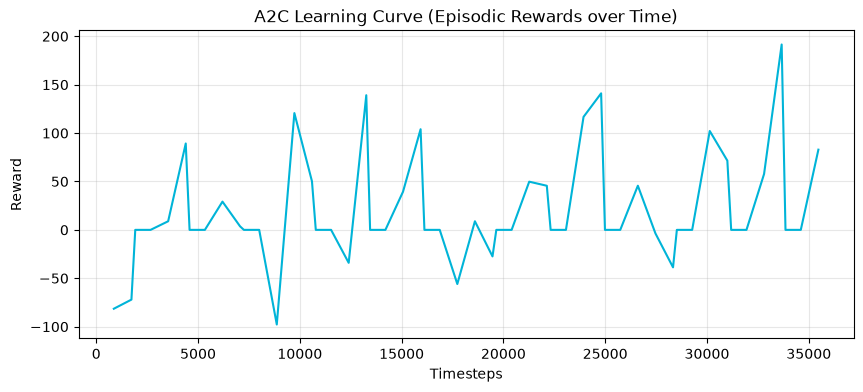

--- Final Test Evaluation ---
Total Profit Ratio: 1.000x
Total Reward: 0.000


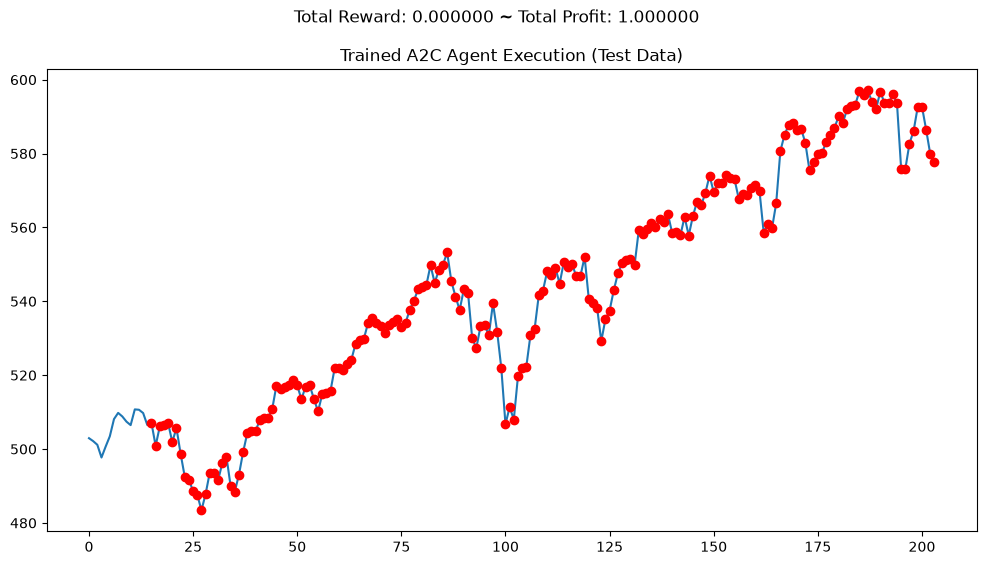

In [26]:
from stable_baselines3.common.results_plotter import load_results, ts2xy
import matplotlib.pyplot as plt

# 1. Plot the Learning Curve
results = load_results('logs')
x, y = ts2xy(results, 'timesteps')
plt.figure(figsize=(10, 4))
plt.plot(x, y, color='#00b4d8')
plt.title('A2C Learning Curve (Episodic Rewards over Time)')
plt.xlabel('Timesteps')
plt.ylabel('Reward')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Load the Best Model
best_model = A2C.load('./models/best_model.zip')

# 3. Create the unseen Test Environment
env_test = gym.make('stocks-v0', df=df, frame_bound=test_bound, window_size=window_size)
obs, info = env_test.reset(seed=42)

# 4. Run the Agent on Test Data
while True:
    action, _states = best_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(action)
    if terminated or truncated:
        print("--- Final Test Evaluation ---")
        print(f"Total Profit Ratio: {info['total_profit']:.3f}x")
        print(f"Total Reward: {info['total_reward']:.3f}")
        break

# 5. Visualize the Test Trades
# (Reusing the plot_rl_trades function from earlier, if you define it!)
# Let's write a quick inline version using matplotlib for simplicity
plt.figure(figsize=(12, 6))
env_test.unwrapped.render_all()
plt.title("Trained A2C Agent Execution (Test Data)")
plt.show()

## Phase 7: Feature Engineering (The Fix!)

To solve the "Raw Price" non-stationarity trap, we will compute percentage-based relative features so the Neural Network isn't blinded by high absolute prices.

In [27]:
# Compute Stationary Features
df_processed = df.copy()

# 1. Momentum / Return
df_processed['Return'] = df_processed['Close'].pct_change()

# 2. Trend (Distance from 20-day Simple Moving Average)
df_processed['SMA_20'] = df_processed['Close'].rolling(window=20).mean()
df_processed['Dist_SMA_20'] = (df_processed['Close'] - df_processed['SMA_20']) / df_processed['SMA_20']

# 3. Volatility (20-day rolling standard deviation of returns)
df_processed['Volatility_20'] = df_processed['Return'].rolling(window=20).std()

# 4. Relative Volume
df_processed['Vol_SMA_20'] = df_processed['Volume'].rolling(window=20).mean()
df_processed['Relative_Volume'] = df_processed['Volume'] / df_processed['Vol_SMA_20']

# Drop NaN values caused by the 20-day rolling windows
df_processed.dropna(inplace=True)

print("Feature Engineering Complete!")
display(df_processed[['Close', 'Return', 'Dist_SMA_20', 'Volatility_20', 'Relative_Volume']].head())

Feature Engineering Complete!


,Close,Return,Dist_SMA_20,Volatility_20,Relative_Volume
Date,,,,,
2020-01-31,294.018738,-0.018158,-0.016357,0.007553,1.708300
2020-02-03,296.202698,0.007428,-0.009309,0.007554,1.043372
2020-02-04,300.717224,0.015241,0.004958,0.008236,0.940141
2020-02-05,304.190002,0.011548,0.014994,0.008519,0.972300
2020-02-06,305.213440,0.003364,0.016931,0.008485,0.752388


## Phase 8: The Advanced Custom Environment

Now we subclass `StocksEnv`. The trick here is that we use the **Raw Prices** to calculate our real-world profit, but we *only* expose our **Stationary Features** to the AI!

In [28]:
from gym_anytrading.envs import StocksEnv
import numpy as np

class AdvancedSPYEnv(StocksEnv):
    def _process_data(self):
        # Raw prices for calculating actual profit/loss
        prices = self.df['Close'].to_numpy()
        
        # Stationary features for the AI's observation space
        # Notice we DO NOT give the AI the raw 'Close' price anymore!
        features = self.df[['Return', 'Dist_SMA_20', 'Volatility_20', 'Relative_Volume']].to_numpy()
        
        return prices, features

# Quick Test to verify Observation Space Shape
test_env = AdvancedSPYEnv(df=df_processed, frame_bound=(15, 100), window_size=15)
print(f"New Observation Space Shape: {test_env.observation_space.shape}")
print("(15 days of history, 4 feature columns)")

New Observation Space Shape: (15, 4)
(15 days of history, 4 feature columns)


## Phase 9: Training the Advanced Agent (Version 2.0)

We recalculate our Train/Val/Test splits for `df_processed` and spin up a brand new A2C model. Let's see if our feature engineering fixes the flatlining issue!

/home/neelavro/projects/rl_project/.venv/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training Advanced Agent (v2.0)...
Eval num_timesteps=2000, episode_reward=0.00 +/- 0.00
Episode length: 1222.00 +/- 0.00
New best mean reward!
Eval num_timesteps=4000, episode_reward=72.84 +/- 0.00
Episode length: 1222.00 +/- 0.00
New best mean reward!
Eval num_timesteps=6000, episode_reward=-8.85 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_timesteps=8000, episode_reward=0.00 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_timesteps=10000, episode_reward=339.82 +/- 0.00
Episode length: 1222.00 +/- 0.00
New best mean reward!
Eval num_timesteps=12000, episode_reward=102.51 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_timesteps=14000, episode_reward=0.00 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_timesteps=16000, episode_reward=208.19 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_timesteps=18000, episode_reward=37.07 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_timesteps=20000, episode_reward=64.82 +/- 0.00
Episode length: 1222.00 +/- 0.00
Eval num_times

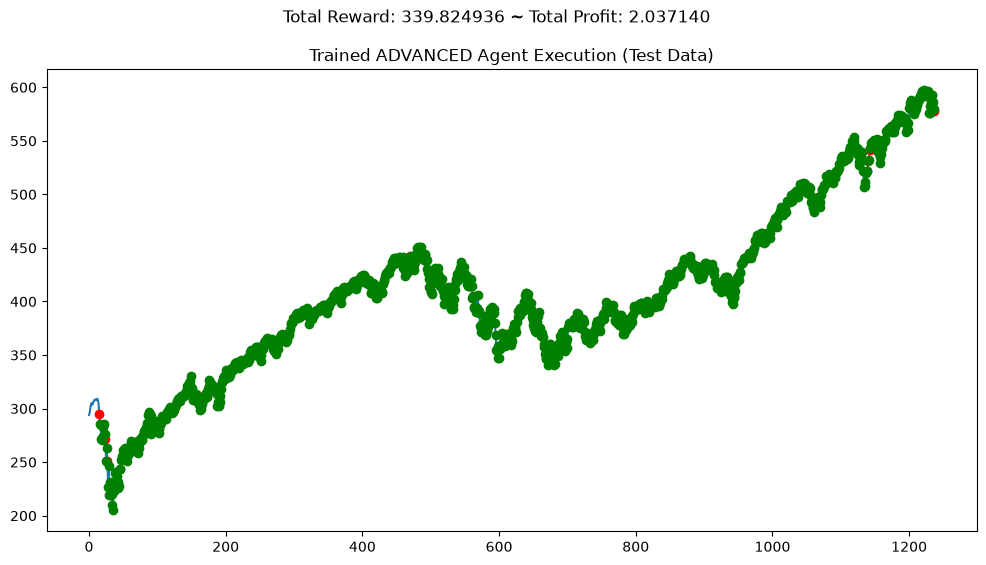

In [29]:
# 1. Recalculate Boundaries (since we dropped 20 rows of NaN)
total_len_adv = len(df_processed)
train_split_adv = int(total_len_adv * 0.7)
val_split_adv = int(total_len_adv * 0.85)

train_bound_adv = (window_size, train_split_adv)
val_bound_adv = (train_split_adv, val_split_adv)
test_bound_adv = (val_split_adv, total_len_adv)

# 2. Create Advanced Environments
env_train_adv = AdvancedSPYEnv(df=df_processed, frame_bound=train_bound_adv, window_size=window_size)
env_val_adv = AdvancedSPYEnv(df=df_processed, frame_bound=val_bound_adv, window_size=window_size)

env_train_adv = DummyVecEnv([lambda: Monitor(env_train_adv, 'logs/train_adv_log')])
env_val_adv = DummyVecEnv([lambda: Monitor(env_val_adv, 'logs/val_adv_log')])

# 3. Setup Callback & Initialize Model
os.makedirs('models/adv', exist_ok=True)
eval_callback_adv = EvalCallback(env_val_adv, best_model_save_path='./models/adv/',
                                 log_path='./logs/adv/', eval_freq=2000,
                                 deterministic=True, render=False)

model_adv = A2C('MlpPolicy', env_train_adv, verbose=0)

# 4. Train!
print("Training Advanced Agent (v2.0)...")
model_adv.learn(total_timesteps=25000, callback=eval_callback_adv)
print("Training Complete!")

# 5. Final Evaluation
best_model_adv = A2C.load('./models/adv/best_model.zip')
env_test_adv = AdvancedSPYEnv(df=df_processed, frame_bound=test_bound_adv, window_size=window_size)
obs, info = env_test_adv.reset(seed=42)

while True:
    action, _ = best_model_adv.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test_adv.step(action)
    if terminated or truncated:
        print("\n--- Advanced Final Test Evaluation ---")
        print(f"Total Profit Ratio: {info['total_profit']:.3f}x")
        print(f"Total Reward: {info['total_reward']:.3f}")
        break

# 6. Plot the Execution
plt.figure(figsize=(12, 6))
env_test_adv.render_all()
plt.title("Trained ADVANCED Agent Execution (Test Data)")
plt.show()

Loading the best Advanced Agent...

--- Final Trading Results ---
Total Profit Multiplier: 2.037x


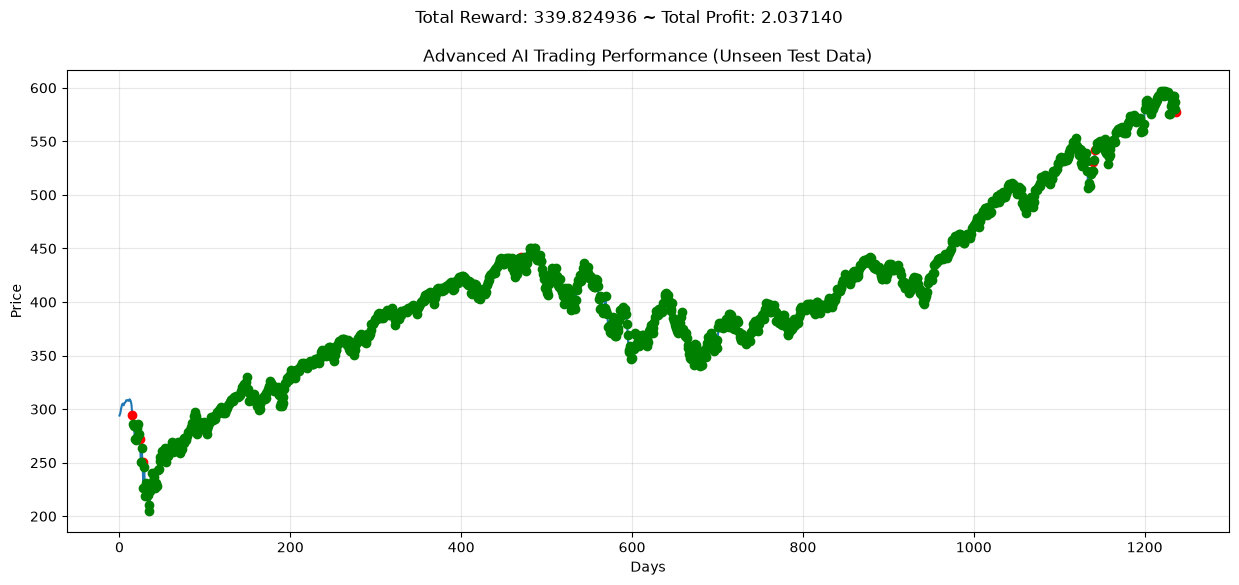

In [30]:
import matplotlib.pyplot as plt
from stable_baselines3 import A2C

# 1. Load the Best Agent from your hard drive
print("Loading the best Advanced Agent...")
best_model_adv = A2C.load('./models/adv/best_model.zip')

# 2. Re-create the Test Environment
env_test_adv = AdvancedSPYEnv(df=df_processed, frame_bound=test_bound_adv, window_size=window_size)
obs, info = env_test_adv.reset(seed=42)

# 3. Let the Agent trade on the unseen data
while True:
    # deterministic=True forces the agent to take its "best" action, no random exploration
    action, _states = best_model_adv.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test_adv.step(action)
    
    if terminated or truncated:
        print("\n--- Final Trading Results ---")
        print(f"Total Profit Multiplier: {info['total_profit']:.3f}x")
        break

# 4. Plot the trades!
# Green Dots = Agent was holding the stock (Action 1)
# Red Dots = Agent sold/shorted the stock (Action 0)
plt.figure(figsize=(15, 6))
env_test_adv.unwrapped.render_all()
plt.title("Advanced AI Trading Performance (Unseen Test Data)")
plt.ylabel("Price")
plt.xlabel("Days")
plt.grid(True, alpha=0.3)
plt.show()
